In [1]:
import pyorbital
from pyorbital.orbital import Orbital
import datetime as dt
import numpy as np

import networkx as nx

from pathlib import Path
import os

from enum import Enum

from fame import *

import plotly.express as px
from matplotlib.pyplot import cm

# import random


In [2]:
R_earth_km = 6371


In [3]:
# Gemini-generated

# Space-Track Credentials
space_track_user = os.environ.get('SPACE_TRACK_USER'), 
space_track_password = os.environ.get('SPACE_TRACK_PW')


In [4]:
tle_file_name_json = "all_tles_{}.json".format(dt.datetime.now().strftime("%Y%m%d"))
tle_file_name_txt = "all_tles_{}.txt".format(dt.datetime.now().strftime("%Y%m%d"))

if Path(tle_file_name_txt).is_file():
    pass
else:
    if Path(tle_file_name_json).is_file():
        pass
    else:
        all_tles_for_today = get_gp_tles(tle_file_name_json, space_track_user, space_track_password)
    process_tles_from_json(tle_file_name_json, tle_file_name_txt)

Logging in...
Fetching GP TLEs (this may take a few moments)...
Successfully retrieved data.
TLEs saved to all_tles_20260311.json


In [5]:
tle_file_name_txt = "all_tles_20260130.txt"


In [6]:
# planet_satellites = []
# 14-19 decayed

instrument_types = ["RGB", "Hyperspectral", "SAR"]

swaths_at_nadir_km = {
    "SKYSAT-A": 8, # https://www.eoportal.org/satellite-missions/skysat#SkySat.html.53, https://earth.esa.int/eogateway/missions/skysat#instruments-section
    "SKYSAT-B": 8,
    "SKYSAT-C1": 5.9,
    "SKYSAT-C2": 5.9,
    "SKYSAT-C3": 5.9,
    "SKYSAT-C4": 5.9,
    "SKYSAT-C5": 5.9,
    "SKYSAT-C6": 5.9,
    "SKYSAT-C7": 5.9,
    "SKYSAT-C8": 5.9,
    "SKYSAT-C9": 5.9,
    "SKYSAT-C10": 5.9,
    "SKYSAT-C11": 5.9,
    "SKYSAT-C12": 5.9,
    "SKYSAT-C13": 5.9,
    "PELICAN-3001": 8, # https://www.planet.com/constellations/pelican/
    "PELICAN-3009": 8,
    "PELICAN-300A": 8,
    "PELICAN-300B": 8,
    "PELICAN-5": 8,
    "PELICAN-6": 8,
    "TANAGER-4001": 18, # https://www.planet.com/constellations/tanager/
    "UMBRA-07": 8, # https://umbra.space/remote-sensing/scan-mode/
    "UMBRA-09": 8, 
    "UMBRA-10": 8,
    "UMBRA-11": 8, 
    "CAPELLA-11 (ACADIA-1)": 10, #https://support.capellaspace.com/what-are-capellas-collect-modes and https://geokom.ba/wp-content/uploads/2020/12/Capella_Space_SAR_System_Performance.pdf
    "CAPELLA-13 (ACADIA-3)": 10,
    "CAPELLA-14 (ACADIA-4)": 10,
    "CAPELLA-15 (ACADIA-5)": 10,
    "CAPELLA-16 (ACADIA-6)": 10,
    "CAPELLA-17 (ACADIA-7)": 10,
    "LOFT YAM-6": 19.8,
    "Ubotica CogniSat-6 HAMMER": 20,
    "Mission Control Persistence": 100,
    "AEROCUBE 18A": 80,
    "AEROCUBE 18B": 80,
}

skysat_satellites = [
    Satellite("SKYSAT-A", Orbital("SKYSAT 1", tle_file=tle_file_name_txt), instruments=["RGB"]),
    Satellite("SKYSAT-B", Orbital("SKYSAT 2", tle_file=tle_file_name_txt), instruments=["RGB"]),
    Satellite("SKYSAT-C1", Orbital("SKYSAT C1", tle_file=tle_file_name_txt), instruments=["RGB"]),
    # Satellite("SKYSAT-C1", Orbital("SKYSAT C1", tle_file=tle_file_name_txt)),
    Satellite("SKYSAT-C2", Orbital("SKYSAT C2", tle_file=tle_file_name_txt), instruments=["RGB"]),
    Satellite("SKYSAT-C3", Orbital("SKYSAT C3", tle_file=tle_file_name_txt), instruments=["RGB"]),
    Satellite("SKYSAT-C4", Orbital("SKYSAT C4", tle_file=tle_file_name_txt), instruments=["RGB"]),
    Satellite("SKYSAT-C5", Orbital("SKYSAT C5", tle_file=tle_file_name_txt), instruments=["RGB"]),
    Satellite("SKYSAT-C6", Orbital("SKYSAT C6", tle_file=tle_file_name_txt), instruments=["RGB"]),
    Satellite("SKYSAT-C7", Orbital("SKYSAT C7", tle_file=tle_file_name_txt), instruments=["RGB"]),
    Satellite("SKYSAT-C8", Orbital("SKYSAT C8", tle_file=tle_file_name_txt), instruments=["RGB"]),
    Satellite("SKYSAT-C9", Orbital("SKYSAT C9", tle_file=tle_file_name_txt), instruments=["RGB"]),
    Satellite("SKYSAT-C10", Orbital("SKYSAT C10", tle_file=tle_file_name_txt), instruments=["RGB"]),
    Satellite("SKYSAT-C11", Orbital("SKYSAT C11", tle_file=tle_file_name_txt), instruments=["RGB"]),
    Satellite("SKYSAT-C12", Orbital("SKYSAT C12", tle_file=tle_file_name_txt), instruments=["RGB"]),
    Satellite("SKYSAT-C13", Orbital("SKYSAT C13", tle_file=tle_file_name_txt), instruments=["RGB"]),
]
pelican_satellites = [
    Satellite("PELICAN-3001", Orbital("PELICAN 3001", tle_file=tle_file_name_txt), instruments=["RGB"]),
    Satellite("PELICAN-3009", Orbital("PELICAN 3009", tle_file=tle_file_name_txt), instruments=["RGB"]),
    Satellite("PELICAN-300A", Orbital("PELICAN-3", tle_file=tle_file_name_txt), instruments=["RGB"]),
    Satellite("PELICAN-300B", Orbital("PELICAN-4", tle_file=tle_file_name_txt), instruments=["RGB"]),
    Satellite("PELICAN-5", Orbital("PELICAN-5", tle_file=tle_file_name_txt), instruments=["RGB"]),
    Satellite("PELICAN-6", Orbital("PELICAN-6", tle_file=tle_file_name_txt), instruments=["RGB"]),

]
tanager_satellites = [
    Satellite("TANAGER-4001", Orbital("TANAGER 4001", tle_file=tle_file_name_txt), instruments=["Hyperspectral"]),
]
# 1-6 and 8 decayed
umbra_satellites = [
    Satellite("UMBRA-07", Orbital("UMBRA-07", tle_file=tle_file_name_txt), instruments=["SAR"]),
    Satellite("UMBRA-09", Orbital("UMBRA-09", tle_file=tle_file_name_txt), instruments=["SAR"]),
    Satellite("UMBRA-10", Orbital("UMBRA-10", tle_file=tle_file_name_txt), instruments=["SAR"]),
    Satellite("UMBRA-11", Orbital("UMBRA-11", tle_file=tle_file_name_txt), instruments=["SAR"]),
]
capella_acadia_satellites = [
    Satellite("CAPELLA-11 (ACADIA-1)", Orbital("CAPELLA-11 (ACADIA)", tle_file=tle_file_name_txt), instruments=["SAR"]),
    Satellite("CAPELLA-14 (ACADIA-4)", Orbital("CAPELLA-14 (ACADIA)", tle_file=tle_file_name_txt), instruments=["SAR"]),
    Satellite("CAPELLA-13 (ACADIA-3)", Orbital("CAPELLA-13 (ACADIA)", tle_file=tle_file_name_txt), instruments=["SAR"]),
    Satellite("CAPELLA-15 (ACADIA-5)", Orbital("CAPELLA-15 (ACADIA)", tle_file=tle_file_name_txt), instruments=["SAR"]),
    Satellite("CAPELLA-17 (ACADIA-7)", Orbital("CAPELLA-17 (ACADIA)", tle_file=tle_file_name_txt), instruments=["SAR"]),
    Satellite("CAPELLA-16 (ACADIA-6)", Orbital("CAPELLA-16 (ACADIA)", tle_file=tle_file_name_txt), instruments=["SAR"]),
]
# Whitneys all decayes
# capella_whitney_satellites = [
#     Satellite("CAPELLA-4-WHITNEY",  Orbital("CAPELLA-4-WHITNEY")),
#     Satellite("CAPELLA-3-WHITNEY",  Orbital("CAPELLA-3-WHITNEY")),
#     Satellite("CAPELLA-6-WHITNEY",  Orbital("CAPELLA-6-WHITNEY")),
#     Satellite("CAPELLA-5-WHITNEY",  Orbital("CAPELLA-6-WHITNEY")),
#     Satellite("CAPELLA-8-WHITNEY",  Orbital("CAPELLA-8-WHITNEY")),
#     Satellite("CAPELLA-7-WHITNEY",  Orbital("CAPELLA-7-WHITNEY")),
#     Satellite("CAPELLA-10-WHITNEY", Orbital("CAPELLA-10-WHITNEY")),
#     Satellite("CAPELLA-9-WHITNEY",  Orbital("CAPELLA-9-WHITNEY")),
# ]


loft_satellites = [Satellite("LOFT YAM-6", Orbital("YAM-6", tle_file=tle_file_name_txt), instruments=["RGB"])]
ubotica_satellites = [Satellite("Ubotica CogniSat-6 HAMMER", Orbital("HAMMER", tle_file=tle_file_name_txt), instruments=["RGB"])]
mission_control_satellites = [Satellite("Mission Control Persistence", Orbital("LEMUR 2 KRISH", tle_file=tle_file_name_txt), instruments=["RGB"]),]
aerospace_corp_satellites = [
    Satellite("AEROCUBE 18A", Orbital("AEROCUBE 18A", tle_file=tle_file_name_txt), instruments=["RGB"]),
    Satellite("AEROCUBE 18B", Orbital("AEROCUBE 18B", tle_file=tle_file_name_txt), instruments=["RGB"]),   
]

for sat in skysat_satellites:
    sat.isl_links = {s: 250 for s in skysat_satellites+pelican_satellites+tanager_satellites if s!=sat }
for sat in pelican_satellites:
    sat.isl_links = {s: 250 for s in skysat_satellites+pelican_satellites+tanager_satellites if s!=sat }
for sat in tanager_satellites:
    sat.isl_links = {s: 250 for s in skysat_satellites+pelican_satellites+tanager_satellites if s!=sat }

for sat in umbra_satellites:
    sat.isl_links = {s: 250 for s in umbra_satellites if s!=sat }

for sat in capella_acadia_satellites:
    sat.isl_links = {s: 250 for s in capella_acadia_satellites if s!=sat }

for sat in aerospace_corp_satellites:
    sat.isl_links = {s: 250 for s in aerospace_corp_satellites if s!=sat }


In [7]:
all_satellites = skysat_satellites+pelican_satellites+tanager_satellites+umbra_satellites+capella_acadia_satellites+loft_satellites+ubotica_satellites+mission_control_satellites

In [8]:
for _sat in all_satellites:
    _semi_major_axis = _sat.orbit.orbit_elements.semi_major_axis * pyorbital.orbital.A
    _mean_altitude = _semi_major_axis-pyorbital.orbital.A
    _fov = 2*np.atan2(swaths_at_nadir_km[_sat.name]/2, _mean_altitude)
    _sat.instrument_fov_rad = {"RGB": _fov}

In [9]:
def satcolorer(sat_name):
    # Planet: shades of blue
    if "SKYSAT" in sat_name:
        return "midnightblue"
    if "PELICAN" in sat_name:
        return "mediumblue"
    if "TANAGER" in sat_name:
        return "blueviolet"
    # Black
    if "UMBRA" in sat_name:
        return "dimgray"
    # Yellow/orange
    if "CAPELLA" in sat_name:
        return "darkorange"
    # 
    if "LOFT" in sat_name:
        return "forestgreen"
    #
    if "Ubotica" in sat_name:
        return "lime"
    #
    if "Mission Control" in sat_name:
        return "orchid"
    return "red"
    
def constcolorer(constellation_name):
    # Planet: shades of blue
    if "PLANET" in constellation_name:
        return "blue"
    # Black
    if "UMBRA" in constellation_name:
        return "gray"
    # Yellow/orange
    if "CAPELLA" in constellation_name:
        return "darkorange"
    # 
    if "LOFT" in constellation_name:
        return "forestgreen"
    #
    if "Ubotica" in constellation_name:
        return "lime"
    #
    if "Mission Control" in constellation_name:
        return "orchid"
    return "red"

def satmarkerer(sat_name):
    # Planet: shades of blue
    if "SKYSAT" in sat_name:
        return "p"
    if "PELICAN" in sat_name:
        return "p"
    if "TANAGER" in sat_name:
        return "p"
    # Black
    if "UMBRA" in sat_name:
        return "D"
    # Yellow/orange
    if "CAPELLA" in sat_name:
        return "D"
    # 
    if "LOFT" in sat_name:
        return "p"
    #
    if "Ubotica" in sat_name:
        return "p"
    #
    if "Mission Control" in sat_name:
        return "p"
    return "."

satcolor = {sat.name: satcolorer(sat.name) for sat in all_satellites}

satmarker = {sat.name: satmarkerer(sat.name) for sat in all_satellites}

constcolor = {sat.name: satmarkerer(sat.name) for sat in all_satellites}


In [10]:
Rotterdam = Location(3.8, 52, 0, "Rotterdam-ish")

ground_stations = [
    Location(
        3.8,
        52,
        0,
        "Rotterdam-ish",
    ),
]

# ground_station_opportunities = [
#     observation_request(
#         lon_deg=gs.lon_deg,
#         lat_deg=gs.lat_deg,
#         alt_km=gs.alt_km,
#         min_time=dt.datetime.now(dt.timezone.utc),
#         max_time=dt.datetime.now(dt.timezone.utc)+ dt.timedelta(seconds=3600*24*2)
#     )
#     for gs in ground_stations
# ]

## Let's now look at communication opportunities

In [11]:

ground_stations = [
    Location(
        -79.55,
        8.9833,
        0.028,
        "KSAT Panama",
    ),
    Location(
        -51.73363,
        64.182789,
        0,
        "KSAT Nuuk",
    ),
    Location(
        2.53219,
        -72.01243,
        0,
        "KSAT Troll",
    ),
    Location(
        142.3689,
        43.8,
        0,
        "KSAT Hokkaido",
    ),
    Location(
        103.9915,
        1.3661,
        0,
        "KSAT Singapore",
    ),
    Location(
        -70.85021,
        -52.93279,
        0,
        "KSAT Punta Arenas",
    ),
    Location(
        127.7766,
        26.4055,
        0,
        "KSAT Okinawa",
    ),
    Location(
        57.5565,
        -20.1142,
        0,
        "KSAT Mauritius",
    ),
    Location(
        22.62216,
        37.84604,
        0,
        "KSAT Nemea",
    ),
    Location(
        31.12509,
        70.36779,
        0,
        "KSAT Vardo",
    ),
    Location(
        15.39964,
        78.22875,
        0,
        "KSAT Svalbard",
    ),
]

In [12]:
min_time=dt.datetime.now(dt.timezone.utc)
max_time=dt.datetime.now(dt.timezone.utc)+ dt.timedelta(seconds=3600*24*2)

In [13]:
comm_opportunities_by_sat_and_station, comm_opportunities_by_sat = find_contact_opportunities(
    ground_stations=ground_stations,
    satellites=all_satellites,
    min_time=min_time,
    max_time=max_time,
    passes_error_s=60,
    passes_horizon_deg=45
)

/Users/frossi/.local/share/mamba/envs/aig-fame/lib/python3.13/site-packages/pyorbital/__init__.py:30: UserWarning: no explicit representation of timezones available for np.datetime64
  return utc_time.astype("datetime64[ns]")
/Users/frossi/.local/share/mamba/envs/aig-fame/lib/python3.13/site-packages/pyorbital/__init__.py:28: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.datetime64(utc_time)


In [14]:
isl_links = find_isl_opportunities(all_satellites, min_time, max_time)
isl_links

[ISL link from SKYSAT-C7 to SKYSAT-C9 at 2026-03-11 20:22:08.225409+00:00,
 ISL link from SKYSAT-C9 to SKYSAT-C7 at 2026-03-11 20:22:08.225409+00:00,
 ISL link from SKYSAT-C7 to SKYSAT-C9 at 2026-03-11 20:23:08.225409+00:00,
 ISL link from SKYSAT-C9 to SKYSAT-C7 at 2026-03-11 20:23:08.225409+00:00,
 ISL link from SKYSAT-C7 to SKYSAT-C9 at 2026-03-11 20:24:08.225409+00:00,
 ISL link from SKYSAT-C9 to SKYSAT-C7 at 2026-03-11 20:24:08.225409+00:00,
 ISL link from SKYSAT-C7 to SKYSAT-C9 at 2026-03-11 20:25:08.225409+00:00,
 ISL link from SKYSAT-C9 to SKYSAT-C7 at 2026-03-11 20:25:08.225409+00:00,
 ISL link from SKYSAT-C7 to SKYSAT-C9 at 2026-03-11 20:26:08.225409+00:00,
 ISL link from SKYSAT-C9 to SKYSAT-C7 at 2026-03-11 20:26:08.225409+00:00,
 ISL link from SKYSAT-C7 to SKYSAT-C9 at 2026-03-11 20:27:08.225409+00:00,
 ISL link from SKYSAT-C9 to SKYSAT-C7 at 2026-03-11 20:27:08.225409+00:00,
 ISL link from SKYSAT-C7 to SKYSAT-C9 at 2026-03-11 20:28:08.225409+00:00,
 ISL link from SKYSAT-C9 

In [15]:
# So it looks like nx-temporal loses track of times when unrolling the graph.
# What we would like is:
# - Build an unrolled temporal graph from the events.
#   - Make a list of all time steps
#   - Create copies of nodes for each time step
#   - Create edges between the same node at subsequent time steps
#   - Create edges between different nodes according to contact graph, ISL links
#   - ADD WEIGHTS TO EDGES corresponding to the duration of that edge
#   - For shortest time: add edges from all copies of a node to node_EARLIEST with cost 0.

In [16]:
contact_graph, contact_graph_times = build_unrolled_temporal_graph(comm_opportunities_by_sat, isl_links)
print(contact_graph)

DiGraph with 98360 nodes and 568670 edges


In [17]:
# _path = nx.shortest_path(
#     contact_graph,
#     source='KSAT Svalbard_1772155731.586991',
#     # source='PELICAN-6_1772155731.586991',
#     target='KSAT Svalbard_EARLIEST_OUT',
#     weight=duration
#     )
# print(_path)

In [18]:
# nx.shortest_path(
#     contact_graph,
#     source='KSAT Svalbard_1772155731.586991',
#     # source='PELICAN-6_1772155731.586991',
#     target="PELICAN-6_1772328524.397859",
#     weight=duration
#     )

# shortest_path_between_stations(ground_stations[-1], pelican_satellites[-1], start_time= min_time, contact_graph=contact_graph, contact_graph_times=contact_graph_times)

In [19]:
shortest_path_between_stations(pelican_satellites[0].name, pelican_satellites[-1].name, start_time= min_time, contact_graph=contact_graph, contact_graph_times=contact_graph_times)

([{'station': PELICAN-3001,
   'station_type': 'satellite',
   'time': datetime.datetime(2026, 3, 11, 20, 23, 8, 225409, tzinfo=datetime.timezone.utc)},
  {'station': PELICAN-3001,
   'station_type': 'satellite',
   'time': datetime.datetime(2026, 3, 12, 1, 16, 39, 609106, tzinfo=datetime.timezone.utc)},
  {'station': Location KSAT Troll | Lon 2.53219°, lat -72.01243°, alt 0 km,
   'station_type': 'ground_station',
   'time': datetime.datetime(2026, 3, 12, 1, 16, 39, 609106, tzinfo=datetime.timezone.utc)},
  {'station': Location KSAT Hokkaido | Lon 142.3689°, lat 43.8°, alt 0 km,
   'station_type': 'ground_station',
   'time': datetime.datetime(2026, 3, 12, 1, 16, 39, 609106, tzinfo=datetime.timezone.utc)},
  {'station': Location KSAT Hokkaido | Lon 142.3689°, lat 43.8°, alt 0 km,
   'station_type': 'ground_station',
   'time': datetime.datetime(2026, 3, 12, 1, 22, 38, 976865, tzinfo=datetime.timezone.utc)},
  {'station': PELICAN-6,
   'station_type': 'satellite',
   'time': datetime.d

In [20]:
# _path = nx.shortest_path(
#     contact_graph,
#     source=f'KSAT Svalbard_{min_time.timestamp()}',
#     # source='PELICAN-6_1772155731.586991',
#     target="PELICAN-6_EARLIEST_OUT",
#     weight=lambda s, t, edge: edge['duration'].total_seconds()
#     )
# print(_path)

In [21]:
_sp, _ = shortest_path_between_stations(pelican_satellites[0], mission_control_satellites[-1], start_time= min_time, contact_graph=contact_graph, contact_graph_times=contact_graph_times)
print(_sp)

[{'station': PELICAN-3001, 'station_type': 'satellite', 'time': datetime.datetime(2026, 3, 11, 20, 23, 8, 225409, tzinfo=datetime.timezone.utc)}, {'station': PELICAN-3001, 'station_type': 'satellite', 'time': datetime.datetime(2026, 3, 12, 1, 16, 39, 609106, tzinfo=datetime.timezone.utc)}, {'station': Location KSAT Troll | Lon 2.53219°, lat -72.01243°, alt 0 km, 'station_type': 'ground_station', 'time': datetime.datetime(2026, 3, 12, 1, 16, 39, 609106, tzinfo=datetime.timezone.utc)}, {'station': Location KSAT Troll | Lon 2.53219°, lat -72.01243°, alt 0 km, 'station_type': 'ground_station', 'time': datetime.datetime(2026, 3, 12, 2, 53, 51, 570178, tzinfo=datetime.timezone.utc)}, {'station': Mission Control Persistence, 'station_type': 'satellite', 'time': datetime.datetime(2026, 3, 12, 2, 53, 51, 570178, tzinfo=datetime.timezone.utc)}]


/Users/frossi/.local/share/mamba/envs/aig-fame/lib/python3.13/site-packages/pyorbital/__init__.py:28: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.datetime64(utc_time)
/Users/frossi/.local/share/mamba/envs/aig-fame/lib/python3.13/site-packages/pyorbital/__init__.py:28: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.datetime64(utc_time)
/Users/frossi/.local/share/mamba/envs/aig-fame/lib/python3.13/site-packages/pyorbital/__init__.py:28: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.datetime64(utc_time)
/Users/frossi/.local/share/mamba/envs/aig-fame/lib/python3.13/site-packages/pyorbital/__init__.py:28: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.datetime64(utc_time)


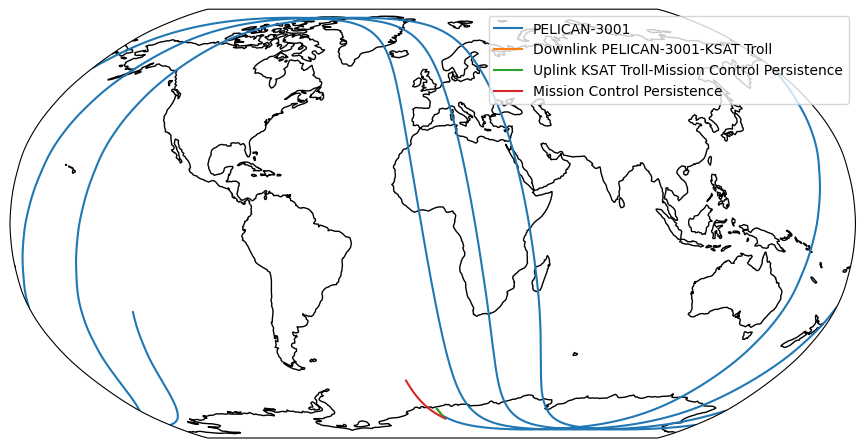

In [22]:
plot_shortest_path_between_stations(_sp)

/Users/frossi/.local/share/mamba/envs/aig-fame/lib/python3.13/site-packages/pyorbital/__init__.py:28: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.datetime64(utc_time)
/Users/frossi/.local/share/mamba/envs/aig-fame/lib/python3.13/site-packages/pyorbital/__init__.py:28: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.datetime64(utc_time)
/Users/frossi/.local/share/mamba/envs/aig-fame/lib/python3.13/site-packages/pyorbital/__init__.py:28: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.datetime64(utc_time)
/Users/frossi/.local/share/mamba/envs/aig-fame/lib/python3.13/site-packages/pyorbital/__init__.py:28: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.datetime64(utc_time)
/Users/frossi/.local/share/mamba/envs/aig-fame/lib/python3.13/site-packages/pyorbital/__init__.py:28: UserWarning: no explicit represent

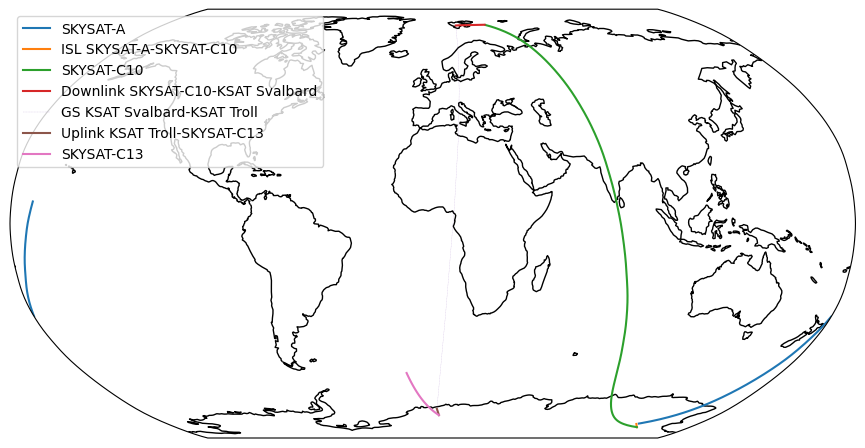

In [23]:
_sp, _ = shortest_path_between_stations(skysat_satellites[0], skysat_satellites[-1], start_time= min_time, contact_graph=contact_graph, contact_graph_times=contact_graph_times)
plot_shortest_path_between_stations(_sp)

In [24]:
# def copy_contact_graph(contact_graph, node_prefix=""):
#     new_contact_graph = nx.DiGraph()
#     for node_label in contact_graph.nodes():
#         node_props = contact_graph.nodes[node_label]
#         new_contact_graph.add_node(node_prefix+node_label, **node_props)
#         # new_contact_graph[node_prefix+node_label]['prefix']= node_prefix
#     for edge_label in contact_graph.edges():
#         edge_props = contact_graph.edges[edge_label]
#         new_contact_graph.add_edge(node_prefix+edge_label[0], node_prefix+edge_label[1], **edge_props)
#         # new_contact_graph.edges[(node_prefix+edge_label[0], node_prefix+edge_label[1])]['prefix'] = node_prefix
#     return new_contact_graph

In [25]:
# new_cg = copy_contact_graph(contact_graph=contact_graph, node_prefix='pre_')

In [26]:
def find_nodes_closest_to_time(station, desired_time: dt.datetime, contact_graph_times: list):

    insert_index = bisect.bisect(contact_graph_times, desired_time)
    if insert_index == len(contact_graph_times):
        # Last entry, so there is no node after that
        # return ValueError("Node is after end time for contact graph")
        closest_time_post = None
        node_name_post = None
    else: 
        closest_time_post = contact_graph_times[insert_index]
        node_name_post = f"{station.name}_{closest_time_post.timestamp()}"
    if insert_index == 0:
        # First entry, so there is no node before that
        closest_time_pre = None
        node_name_pre = None
        # return ValueError("Node is before start time for contact graph")
    else:
        closest_time_pre = contact_graph_times[insert_index-1]
        node_name_pre = f"{station.name}_{closest_time_pre.timestamp()}"

    return (node_name_pre, node_name_post)

In [27]:
def schedule_request_on_contact_graph(
        request: ObservationRequest,
        current_time: dt.datetime,
        satellites,
        contact_graph,
        contact_graph_times,
        current_planner_node,
        data_sink_node
        ):
    
    # Find ObservationOpportunity list
    print("Finding obs opportunities")
    opportunities = find_observation_opportunities(observation_requests=[request], satellites=satellites)
    if len(opportunities) == 0:
        # TODO error handling
        return None, None
    
    passes = opportunities[request]

    # Make a copy of the contact graph
    # planning_graph = copy.deepcopy(contact_graph)

    # planning_graph_pre = copy_contact_graph(contact_graph, node_prefix="PRE_")
    # planning_graph_post = copy_contact_graph(contact_graph, node_prefix="POST_")
    prefix_pre_obs =  'PRE_'
    prefix_post_obs = 'POST_'

    print("Building extended graph")
    planning_graph = nx.union(contact_graph, contact_graph, rename=(prefix_pre_obs, prefix_post_obs))

    planning_graph.add_node("DATA_SINK")
        
    # Annotate the contact graph with rewards corresponding to the observation on the right edges
    for edge in planning_graph.edges():
        planning_graph.edges[edge]['inverse_quality'] = 0

    print("Adding observation edges")
    for satellite, satpasses in passes.items():
        for satpass in satpasses:
            obspass = satpass.highest
            _quality = observation_quality(obspass)

            # Recall that:
            # - You want to minimize cost
            # - You start on the PRE side
            # - You end on the POST side
            # - Only edges that go PRE to POST are costly
            # - So minimize cost=traverse at the lowest-cost edge 

            # Find the edge corresponding to satellite satellite at time satpass.highest.time
            (node_name_before, node_name_after) = find_nodes_closest_to_time(satellite, obspass.time, contact_graph_times)
            # Modify the contact graph so we exit after one request is fulfilled, adding a sink node and removing others
            planning_graph.add_edge(
                prefix_pre_obs+node_name_before,
                prefix_post_obs+node_name_after,
                time=contact_graph.edges[node_name_before, node_name_after]['time'],
                duration=contact_graph.edges[node_name_before, node_name_after]['duration'],
                source_station=contact_graph.edges[node_name_before, node_name_after]['source_station'],
                target_station=contact_graph.edges[node_name_before, node_name_after]['target_station'],
                source_station_type=contact_graph.edges[node_name_before, node_name_after]['source_station_type'],
                target_station_type=contact_graph.edges[node_name_before, node_name_after]['target_station_type'],
                inverse_quality=1./_quality,
                observation=obspass,
                )

    source_station = prefix_pre_obs+current_planner_node.name

    target_station = prefix_post_obs+data_sink_node.name
    
    print("Searching")
    # Shortest path!
    abbreviated_path, _path = shortest_path_between_stations(
        source_station,
        target_station,
        start_time=current_time,
        contact_graph=planning_graph,
        contact_graph_times=contact_graph_times,
        edge_cost=lambda s, t, edge: edge['inverse_quality']
        )
    
    # Now what was the observation we picked?
    observations = []
    for node_index in range(len(_path)-1):
        # _edge = (_path[node_index], _path[node_index+1])
        if 'observation' in planning_graph.edges[_path[node_index], _path[node_index+1]].keys():
            _observation = planning_graph.edges[_path[node_index], _path[node_index+1]]['observation']
            _satellite = planning_graph.edges[_path[node_index], _path[node_index+1]]['source_station']
            observations.append((_satellite, _observation))

    return observations, abbreviated_path, _path

    # TODO Report (i) observation opportunity and (ii) full uplink and downlink path

In [28]:
obs_request = ObservationRequest(
    Rotterdam.lon_deg,
    Rotterdam.lat_deg,
    min_time=min_time,
    max_time=max_time,
    alt_km=Rotterdam.alt_km,
    request_name="Test request in Rotterdam",
    min_elevation_deg=45,
    instrument="RGB"
    )

schedule_request_on_contact_graph(
    obs_request,
    current_time=min_time,
    satellites=all_satellites,
    contact_graph=contact_graph,
    contact_graph_times=contact_graph_times,
    current_planner_node=ground_stations[0],
    data_sink_node=ground_stations[0]
    )

/Users/frossi/.local/share/mamba/envs/aig-fame/lib/python3.13/site-packages/pyorbital/__init__.py:30: UserWarning: no explicit representation of timezones available for np.datetime64
  return utc_time.astype("datetime64[ns]")
/Users/frossi/.local/share/mamba/envs/aig-fame/lib/python3.13/site-packages/pyorbital/__init__.py:28: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.datetime64(utc_time)


Finding obs opportunities
Building extended graph
Adding observation edges
Searching


([(SKYSAT-C5,
   Observation  at 2026-03-12 08:52:42.923657+00:00 with RGB. Look angle 267.8441712909869 | 76.40878859139205 az/dec deg, zenith angle 67.2711927965696 deg, range 484.0266981376856 km, duration 0:01:00)],
 [{'station': Location KSAT Panama | Lon -79.55°, lat 8.9833°, alt 0.028 km,
   'station_type': 'ground_station',
   'time': datetime.datetime(2026, 3, 11, 20, 23, 8, 225409, tzinfo=datetime.timezone.utc)},
  {'station': Location KSAT Panama | Lon -79.55°, lat 8.9833°, alt 0.028 km,
   'station_type': 'ground_station',
   'time': datetime.datetime(2026, 3, 12, 8, 45, 7, 675694, tzinfo=datetime.timezone.utc)},
  {'station': Location KSAT Svalbard | Lon 15.39964°, lat 78.22875°, alt 0 km,
   'station_type': 'ground_station',
   'time': datetime.datetime(2026, 3, 12, 8, 45, 7, 675694, tzinfo=datetime.timezone.utc)},
  {'station': SKYSAT-C5,
   'station_type': 'satellite',
   'time': datetime.datetime(2026, 3, 12, 8, 45, 7, 675694, tzinfo=datetime.timezone.utc)},
  {'statio

# What is a workflow?

We had described a workflow as:
- A task or bag of tasks
- whose completion spawns other tasks (implicitly creating both a START_AFTER_END constraint, and an information dependency).

We need to handle two cases: (i) the next location is unknown and (ii) the next location is known, but there is a Boolean gate.
Do we want more complex constraints? It would be nice to have a CONCURRENT constraint. Or START_AFTER_START.
How about we stsart with the simple stuff?
We will then implement ~~two~~ three algorithms for scheduling.
- Priority heuristic
- ILP
- Network flow (as above) only for START_AFTER_END

Let's start defining the format.

A workflow is (i) a set of ObservationRequests with (ii) dependency constraints of the type START_AFTER_END, CONCURRENT, START_AFTER_START, (iii) Boolean constraints of the type START_IF_SUCCESSFUL, START_IF_FAILED (which imply START_AFTER_END dependency), and (iv) geometry constraints of the form DATA.
We distinguish the Boolean and geometry constriants because the latter does not allow early scheduling.

There is a recursive form of this. We will not use it initially, and use an interpreter to translate the unrolled form to the recursive form.

A set of (ObservationRequest, Dependency (dict with other ObsRequest as key, and obs type as value), BooleanConstraint (dict with other ObsRequest as key, and obs type as value), GeometryConstraint (dict with other ObsRequest as key, and obs type as value))

Note we are also implicitly defining an output format for observation requests' data products: these need to, at a minimum, return a boolean success, and (if required) geometric data information. That is really an execution constraint.


In [29]:
class ConstraintClass(Enum):
    TEMPORAL = 0
    SUCCESS = 1
    GEOMETRY = 2

class TemporalConstraintType(Enum):
    START_AFTER = 0 # Next task starts after this one
    START_AFTER_OFFSET = 1 # Next task starts after this one with an offset of H hours (which can be positive or negative)
    START_BEFORE = 2 # Next task starts before this one
    START_BEFORE_OFFSET = 3 # Next task starts before this one, with an offset of H hours

class SuccessConstraintType(Enum):
    START_IF_FAILED = 0
    START_IF_SUCCESSFUL = 1

class GeometryConstraintType(Enum):
    LLA = 0

class Constraint():
    def __init__(self, constraint_class: ConstraintClass, constraint_type, parent: ObservationRequest, parameters: dict={}):
        self.constraint_class = constraint_class
        self.constraint_type = constraint_type
        self.parent = parent
        self.parameters = parameters
    def __str__(self):
        return f"Constraint {self.constraint_class}: {self.constraint_type}. Parent {self.parent}. Params: {self.parameters}"
    def __repr__(self):
        return self.__str__()

In [30]:
class ConstrainedObservationRequest():
    def __init__(
            self,
            observation_request: ObservationRequest,
            constraints: list = [],
            schedule_policy: dict={c: True for c in ConstraintClass},
            commit_policy: dict={c: True for c in ConstraintClass},
            ):
        self.observation_request = observation_request
        self.constraints = constraints
        self.schedule_policy = schedule_policy
        self.commit_policy = commit_policy
        self.observation_opportunity: ObservationOpportunity = None
        self.observation_opportunity_satellite: Satellite = None
        self.scheduled: bool = False
        self.executed: bool = False
    def __str__(self):
        return f"{self.observation_request} with {len(self.constraints)} constraints"
    def __repr__(self):
        return self.__str__()

In [31]:
# Idea:
# Dependency graph: build who depends on whom and ID the roots
# Then greedily walk down the dependency graph
# Input: a list of constrained observation requests
# Workflow:
# Build a dependency graph
# What if there are loops? <Break them>
# Walk through requests
# For each request, find opportunities with start and end time chosen appropriately
# For each opportunity, filter them according to constraints
# Pick the heuristically best opportunity
# Continue

In [32]:
def greedy_schedule_workflow(workflow: list, satellites: list):
    # Build a dependency graph
    workflow_graph = nx.MultiDiGraph()
    for constrained_request in workflow:
        # this_node = request
        workflow_graph.add_node(constrained_request, **constrained_request.__dict__) # Father forgive me for I have sinned against Python

    requests_to_skip_data_not_ready = []
    for constrained_request in workflow:
        # this_node = request
        for constraint in constrained_request.constraints:
            # Check the constraints.
            # If we have a dependency on something that is not executed;
            # and we are asked "don't schedule until that task is executed and we have the information";
            # then just pop the node.
            for _cclass in ConstraintClass:
                if (
                    (constraint.constraint_class == _cclass) and
                    (constrained_request.schedule_policy[_cclass] == False) and 
                    workflow_graph.nodes[constraint.parent]['executed'] == False
                    ):
                    requests_to_skip_data_not_ready.append(constrained_request)
                continue
            workflow_graph.add_edge(
                constraint.parent,
                constrained_request,
                constraint_class=constraint.constraint_class,
                constraint_type=constraint.constraint_type,
                parameters=constraint.parameters,
                )
    
    workflow_graph.remove_nodes_from(requests_to_skip_data_not_ready)

    print(f"WG: {workflow_graph}")
    # Walk through requests
    # root_nodes = [node for node, in_degree in workflow_graph.in_degree() if in_degree == 0]
    # Start with the root nodes
    nodes_to_visit = [node for node, in_degree in workflow_graph.in_degree() if in_degree == 0]
    while len(nodes_to_visit):
        print(f"Nodes to visit: {nodes_to_visit}")
        constrained_request = nodes_to_visit.pop(0)
        print(f"Current request: {constrained_request}")
        min_time = constrained_request.observation_request.min_time
        max_time = constrained_request.observation_request.max_time

        print(f"This request has {len(list(workflow_graph.successors(constrained_request)))} children: {list(workflow_graph.successors(constrained_request))}")
        for child_request in workflow_graph.successors(constrained_request):
            if workflow_graph.nodes[child_request]['scheduled']==True:
                outedges = workflow_graph.get_edge_data(constrained_request, child_request)
                print(f"Child: {child_request}")
                # print(type(workflow_graph.edges[request]))
                for constraint_key, constraint in outedges.items():
                    # print(constraint)
                    match constraint['constraint_class']:
                        case ConstraintClass.TEMPORAL:
                            match constraint['constraint_type']:
                                # These are constraints on the CHILD. So START_AFTER means the parent has to start before
                                case TemporalConstraintType.START_AFTER:
                                    max_time = min(max_time, workflow_graph.nodes[child_request]['observation_opportunity'].time)
                                case TemporalConstraintType.START_AFTER_OFFSET:
                                    # Note the minus: we want parent_time + offset<child_time
                                    offset = constraint['parameters']['offset']
                                    max_time = min(max_time, workflow_graph.nodes[child_request]['observation_opportunity'].time-offset)
                                case TemporalConstraintType.START_BEFORE:
                                    min_time = max(min_time, workflow_graph.nodes[child_request]['observation_opportunity'].time)
                                case TemporalConstraintType.START_BEFORE_OFFSET:
                                    offset = constraint['parameters']['offset']
                                    # Note the - : we want child_time<parent_time+offset
                                    min_time = max(min_time, workflow_graph.nodes[child_request]['observation_opportunity'].time-offset)
                        case ConstraintClass.SUCCESS:
                            # The child needs to know if the parent succeeded. So we constrain the parent to finish before the child
                            max_time = min(max_time, workflow_graph.nodes[child_request]['observation_opportunity'].time)
                        case ConstraintClass.GEOMETRY:
                            max_time = min(max_time, workflow_graph.nodes[child_request]['observation_opportunity'].time)
            else:
                print(f"Skipping constraints for child {child_request}, currently unscheduled")

        print(f"This request has {len(list(workflow_graph.predecessors(constrained_request)))} parents: {list(workflow_graph.predecessors(constrained_request))}")
        for parent_request in workflow_graph.predecessors(constrained_request):
            if workflow_graph.nodes[parent_request]['scheduled']==True:
                inedges = workflow_graph.get_edge_data(parent_request, constrained_request)
                print(f"Parent: {parent_request}")
                # print(type(workflow_graph.edges[request]))
                for constraint_key, constraint in inedges.items():
                    # print(constraint)
                    match constraint['constraint_class']:
                        case ConstraintClass.TEMPORAL:
                            match constraint['constraint_type']:
                                # These are constraints on the CURRENT node. So START_AFTER means the parent has to start before
                                case TemporalConstraintType.START_AFTER:
                                    min_time = max(min_time, workflow_graph.nodes[parent_request]['observation_opportunity'].time)
                                case TemporalConstraintType.START_AFTER_OFFSET:
                                    offset = constraint['parameters']['offset']
                                    min_time = max(min_time, workflow_graph.nodes[parent_request]['observation_opportunity'].time+offset)
                                case TemporalConstraintType.START_BEFORE:
                                    max_time = min(max_time, workflow_graph.nodes[parent_request]['observation_opportunity'].time)
                                case TemporalConstraintType.START_BEFORE_OFFSET:
                                    offset = constraint['parameters']['offset']
                                    max_time = min(max_time, workflow_graph.nodes[parent_request]['observation_opportunity'].time+offset)
                        case ConstraintClass.SUCCESS:
                            # The current node needs to know if the parent succeeded. So we constrain the current node to start after the parent
                            min_time = max(min_time, workflow_graph.nodes[parent_request]['observation_opportunity'].time)
                        case ConstraintClass.GEOMETRY:
                            min_time = max(min_time, workflow_graph.nodes[parent_request]['observation_opportunity'].time)
            else:
                print(f"Skipping constraints for parent {parent_request}, currently unscheduled")
        
        # Search for opportunities
        trimmed_request = ObservationRequest(
            lon_deg = constrained_request.observation_request.lon_deg,
            lat_deg = constrained_request.observation_request.lat_deg,
            min_time = min_time,
            max_time = max_time,
            alt_km = constrained_request.observation_request.alt_km,
            instrument = constrained_request.observation_request.instrument,
            request_name = constrained_request.observation_request.name+"_trimmed",
            min_elevation_deg = constrained_request.observation_request.min_elevation_deg,
        )
        observation_opportunities = find_observation_opportunities([trimmed_request,], satellites)
        workflow_graph.nodes[constrained_request]['observation_opportunities'] = observation_opportunities[trimmed_request]
        # print(f"Found opportunities: {observation_opportunities}")
        if trimmed_request not in observation_opportunities.keys():
            raise ValueError("Could not schedule {}".format(constrained_request))
        passes = observation_opportunities[trimmed_request]
        if len(passes)==0:
            print("Could not schedule {} (no passes)".format(constrained_request))
            continue
            # raise ValueError("Could not schedule {} (no passes)".format(constrained_request))
        
        # print(f"Opportunities: {passes}")
        _best_quality = - np.inf
        _best_satellite = None
        _best_pass = None
        # TODO Yes, yes, O(n) search is ridiculous. I know. Should sort 
        for satellite, satpasses in passes.items():
            for satpass in satpasses:
                _quality = observation_quality(satpass.highest)
                if _quality >= _best_quality:
                    _best_quality = _quality
                    _best_satellite = satellite
                    _best_pass = satpass
        if _best_pass is None:
            raise ValueError("Could not schedule {}".format(constrained_request))

        # Pick the best opportunity
        workflow_graph.nodes[constrained_request]['observation_opportunity'] = _best_pass.highest
        workflow_graph.nodes[constrained_request]['observation_opportunity_satellite'] = _best_satellite
        workflow_graph.nodes[constrained_request]['scheduled']=True

        # Continue
        for child_request in workflow_graph.successors(constrained_request):
            if workflow_graph.nodes[child_request]['scheduled']==False:
            # assert workflow_graph.nodes[child_request]['scheduled']==False, "ERROR: we are traversing the dependency graph in a strange and incorrect way (children)"
                nodes_to_visit.append(child_request)

    return workflow_graph

In [33]:
Rotterdam = Location(3.8, 52, 0, "Rotterdam-ish")
min_time=dt.datetime.now(dt.timezone.utc)
max_time=dt.datetime.now(dt.timezone.utc)+ dt.timedelta(seconds=3600*24*2)

obs_request_initial = ObservationRequest(
    Rotterdam.lon_deg,
    Rotterdam.lat_deg,
    min_time=min_time,
    max_time=max_time,
    alt_km=Rotterdam.alt_km,
    request_name="Initial RGB request in Rotterdam",
    min_elevation_deg=45,
    instrument="RGB"
    )

obs_request_followup_no = ObservationRequest(
    Rotterdam.lon_deg,
    Rotterdam.lat_deg,
    min_time=min_time,
    max_time=max_time,
    alt_km=Rotterdam.alt_km,
    request_name="Follow-up search request in Rotterdam",
    min_elevation_deg=45,
    instrument="RGB"
    )

obs_request_followup_yes = ObservationRequest(
    Rotterdam.lon_deg,
    Rotterdam.lat_deg,
    min_time=min_time,
    max_time=max_time,
    alt_km=Rotterdam.alt_km,
    request_name="Follow-up SAR request in Rotterdam",
    min_elevation_deg=45,
    instrument="SAR"
    )

constrained_initial_observation = ConstrainedObservationRequest(
    observation_request=obs_request_initial
)

constrained_followup_observation = ConstrainedObservationRequest(
    observation_request=obs_request_followup_yes,
    constraints = [
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER, constrained_initial_observation),
        Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.START_IF_SUCCESSFUL, constrained_initial_observation),
        Constraint(ConstraintClass.GEOMETRY, GeometryConstraintType.LLA, constrained_initial_observation),
    ],
)

constrained_followup_search = ConstrainedObservationRequest(
    observation_request=obs_request_followup_no,
    constraints=[
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER, constrained_initial_observation),
        Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.START_IF_FAILED, constrained_initial_observation),
    ]
)

constrained_followup_observation_later = ConstrainedObservationRequest(
    observation_request=obs_request_followup_yes,
    constraints = [
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, constrained_initial_observation, {'offset': dt.timedelta(seconds=3600*3)}),
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, constrained_initial_observation, {'offset': dt.timedelta(seconds=3600*6)}),
        Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.START_IF_SUCCESSFUL, constrained_initial_observation),
        Constraint(ConstraintClass.GEOMETRY, GeometryConstraintType.LLA, constrained_initial_observation),
    ],
    schedule_policy={ConstraintClass.TEMPORAL: True, ConstraintClass.SUCCESS: True, ConstraintClass.GEOMETRY: True},
)

constrained_followup_search_later = ConstrainedObservationRequest(
    observation_request=obs_request_followup_no,
    constraints = [
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, constrained_initial_observation, {'offset': dt.timedelta(seconds=3600*3)}),
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, constrained_initial_observation, {'offset': dt.timedelta(seconds=3600*6)}),
        Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.START_IF_FAILED, constrained_initial_observation),
    ],
)

constrained_followup_observation_later2 = ConstrainedObservationRequest(
    observation_request=obs_request_followup_yes,
    constraints = [
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, constrained_followup_observation_later, {'offset': dt.timedelta(seconds=3600*3)}),
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, constrained_followup_observation_later, {'offset': dt.timedelta(seconds=3600*6)}),
        Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.START_IF_SUCCESSFUL, constrained_followup_observation_later),
        Constraint(ConstraintClass.GEOMETRY, GeometryConstraintType.LLA, constrained_followup_observation_later),
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, constrained_followup_search_later, {'offset': dt.timedelta(seconds=3600*3)}),
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, constrained_followup_search_later, {'offset': dt.timedelta(seconds=3600*6)}),
        Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.START_IF_SUCCESSFUL, constrained_followup_search_later),
        Constraint(ConstraintClass.GEOMETRY, GeometryConstraintType.LLA, constrained_followup_search_later),
    ],
    schedule_policy={ConstraintClass.TEMPORAL: True, ConstraintClass.SUCCESS: True, ConstraintClass.GEOMETRY: True},
)

constrained_followup_search_later2 = ConstrainedObservationRequest(
    observation_request=obs_request_followup_no,
    constraints = [
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, constrained_followup_observation_later, {'offset': dt.timedelta(seconds=3600*3)}),
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, constrained_followup_observation_later, {'offset': dt.timedelta(seconds=3600*6)}),
        Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.START_IF_FAILED, constrained_followup_observation_later),
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, constrained_followup_search_later, {'offset': dt.timedelta(seconds=3600*3)}),
        Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, constrained_followup_search_later, {'offset': dt.timedelta(seconds=3600*6)}),
        Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.START_IF_FAILED, constrained_followup_search_later),
    ],
)

workflow = [
    constrained_initial_observation,
    constrained_followup_observation,
    constrained_followup_search,
    constrained_followup_observation_later,
    constrained_followup_search_later,
    constrained_followup_observation_later2,
    constrained_followup_search_later2,
    ]

In [35]:
wg = greedy_schedule_workflow(workflow=workflow, satellites=all_satellites)

WG: MultiDiGraph with 7 nodes and 26 edges
Nodes to visit: [Request Initial RGB request in Rotterdam with 0 constraints]
Current request: Request Initial RGB request in Rotterdam with 0 constraints
This request has 4 children: [Request Follow-up SAR request in Rotterdam with 3 constraints, Request Follow-up search request in Rotterdam with 2 constraints, Request Follow-up SAR request in Rotterdam with 4 constraints, Request Follow-up search request in Rotterdam with 3 constraints]
Skipping constraints for child Request Follow-up SAR request in Rotterdam with 3 constraints, currently unscheduled
Skipping constraints for child Request Follow-up search request in Rotterdam with 2 constraints, currently unscheduled
Skipping constraints for child Request Follow-up SAR request in Rotterdam with 4 constraints, currently unscheduled
Skipping constraints for child Request Follow-up search request in Rotterdam with 3 constraints, currently unscheduled
This request has 0 parents: []
Nodes to visi

In [36]:
for request in workflow:
    if request in wg.nodes():
        print(f"Request {request}: opportunity {wg.nodes[request]['observation_opportunity']}")
    else:
        print(f"Request {request} was not scheduled")
# wg.nodes[obs_request_followup_no]

Request Request Initial RGB request in Rotterdam with 0 constraints: opportunity Observation  at 2026-03-12 02:32:25.985558+00:00 with RGB. Look angle 259.769683282094 | 48.27376357701611 az/dec deg, zenith angle 121.38312459784629 deg, range 546.099381851969 km, duration 0:01:00
Request Request Follow-up SAR request in Rotterdam with 3 constraints: opportunity Observation  at 2026-03-12 21:49:49.687974+00:00 with RGB. Look angle 255.72638587197432 | 60.13222358844797 az/dec deg, zenith angle 124.60649847016104 deg, range 575.4906588629128 km, duration 0:01:00
Request Request Follow-up search request in Rotterdam with 2 constraints: opportunity Observation  at 2026-03-13 02:30:00.522407+00:00 with RGB. Look angle 259.5142721456392 | 49.871658544235494 az/dec deg, zenith angle 121.27825639606317 deg, range 561.9322426966866 km, duration 0:01:00
Request Request Follow-up SAR request in Rotterdam with 4 constraints: opportunity Observation  at 2026-03-12 08:07:14.008711+00:00 with RGB. Lo

In [37]:
def plot_workflow_schedule(workflow_graph, ax=None):
    if ax is None:
        fig, ax = plt.subplots()

    num_requests = len(workflow_graph)
    request_names = list(workflow_graph.nodes())
    request_colors_list = cm.rainbow(np.linspace(0, 1, num_requests))
    request_colors = {task: request_colors_list[task_ix] for task_ix, task in enumerate(request_names)}

    line_height = .8

    _all_requests_min_time = None 
    _all_requests_max_time = None
    for request in workflow_graph.nodes():
        request_data = workflow_graph.nodes[request]
        # Plot other times where it could have been scheduled.
        for _sat, _opportunities in request_data['observation_opportunities'].items():
            for _opportunity in _opportunities:
                if _all_requests_min_time is None:
                    _all_requests_min_time = _opportunity.rise.time
                else:
                    _all_requests_min_time = min(_all_requests_min_time, _opportunity.rise.time)
                if _all_requests_max_time is None:
                    _all_requests_max_time = _opportunity.fall.time
                else:
                    _all_requests_max_time = max(_all_requests_max_time, _opportunity.fall.time)

    # Annotete the plot
    ax.set_yticks(np.array(range(num_requests))+0.5, request_names)
    for request_ix, request in enumerate(workflow_graph.nodes()):
        request_data = workflow_graph.nodes[request]
        # SHow the constraint intervals
        # For each constraint
        for parent_request in workflow_graph.predecessors(request):
            prequest_data = workflow_graph.nodes[parent_request]
            if (prequest_data['scheduled']):
                parent_time = workflow_graph.nodes[parent_request]['observation_opportunity'].time
                inedges = workflow_graph.get_edge_data(parent_request, request)
                min_time = _all_requests_min_time
                max_time = _all_requests_max_time
                for constraint_key, constraint in inedges.items():
                    # print(constraint)
                    match constraint['constraint_class']:
                        case ConstraintClass.TEMPORAL:
                            match constraint['constraint_type']:
                                # These are constraints on the CURRENT node. So START_AFTER means the parent has to start before
                                case TemporalConstraintType.START_AFTER:
                                    min_time = max(min_time, workflow_graph.nodes[parent_request]['observation_opportunity'].time)
                                case TemporalConstraintType.START_AFTER_OFFSET:
                                    offset = constraint['parameters']['offset']
                                    min_time = max(min_time, workflow_graph.nodes[parent_request]['observation_opportunity'].time+offset)
                                case TemporalConstraintType.START_BEFORE:
                                    max_time = min(max_time, workflow_graph.nodes[parent_request]['observation_opportunity'].time)
                                case TemporalConstraintType.START_BEFORE_OFFSET:
                                    offset = constraint['parameters']['offset']
                                    max_time = min(max_time, workflow_graph.nodes[parent_request]['observation_opportunity'].time+offset)
                        case ConstraintClass.SUCCESS:
                            # The current node needs to know if the parent succeeded. So we constrain the current node to start after the parent
                            min_time = max(min_time, workflow_graph.nodes[parent_request]['observation_opportunity'].time)
                        case ConstraintClass.GEOMETRY:
                            min_time = max(min_time, workflow_graph.nodes[parent_request]['observation_opportunity'].time)
                ax.add_patch(plt.Rectangle((min_time, request_ix), max_time-min_time, line_height, color=request_colors[parent_request], alpha=.1))
        
        # Show where we actually ended up
        if (request_data['scheduled']):
            # Plot the time where the request was scheduled.
            ax.vlines(request_data['observation_opportunity'].time, request_ix, request_ix+line_height, color=request_colors[request], linewidth=3)
            # Plot other times where it could have been scheduled.
            for _sat, _opportunities in request_data['observation_opportunities'].items():
                for _opportunity in _opportunities:
                    _min_time = _opportunity.rise.time
                    _max_time = _opportunity.fall.time
                    ax.add_patch(plt.Rectangle((_min_time, request_ix), _max_time-_min_time, line_height, color=request_colors[request], alpha=.1))

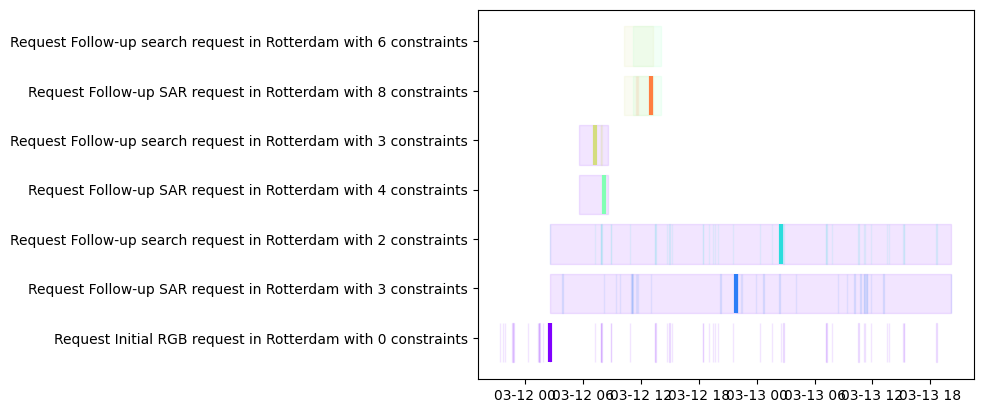

In [38]:
plot_workflow_schedule(wg)